# Improve Training

In [1]:
## Package Import & Path Setting

from pathlib import Path
import pandas as pd
from pandas import DataFrame as df
import numpy as np
import matplotlib.pyplot as plt

# data split
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

# preprocessing & structure
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# pytorch
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

# other imports
from tqdm.auto import tqdm
from sklearn.dummy import DummyClassifier

In [2]:
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
else:
    print("Using CPU version")

PyTorch version: 2.9.1+cu128
CUDA available: True
CUDA version: 12.8


In [ ]:
# helper functions

# baseline model
class LogisticClass(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.linear = nn.Linear(in_dim, 1)
    def forward(self, x):
        return self.linear(x).squeeze(1)

 
# training class
class Trainer():
    def __init__(self, model, optimizer, loss_fn, metrics, device=None):
        self.model = model
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.metrics = metrics
        self.device = device or ("cuda" if torch.cuda.is_available() else "cpu")
        self.hist = {"loss": [], "val_loss": []}
        for name in self.metrics.keys():
            self.hist[name] = []        

    def train(self, train_data, val_data, batch_size, epochs):
        X_tr_np, y_tr_np = train_data
        X_val_np, y_val_np = val_data
        
        X_tr = torch.tensor(X_tr_np, dtype=torch.float32)
        y_tr = torch.tensor(y_tr_np, dtype=torch.float32)
        X_val = torch.tensor(X_val_np, dtype=torch.float32)
        y_val = torch.tensor(y_val_np, dtype=torch.float32)

        if y_tr.ndim == 1:
            y_tr = y_tr.view(-1, 1)
        if y_val.ndim == 1:
            y_val = y_val.view(-1, 1)

        train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size, shuffle=False)             

        # for epoch in range(epochs):
        for epoch in tqdm(range(epochs), desc="Training", leave=False):
            self.model.train()
            total_loss = 0
            total_n = 0
            for x, y in train_loader:
                x = x.to(self.device)
                y = y.to(self.device)
                self.optimizer.zero_grad()
                logits = self.model(x).squeeze()
                loss = self.loss_fn(logits, y.squeeze())
                actual_bs = x.size(0)
                total_loss += loss.item() * actual_bs
                total_n += actual_bs
                loss.backward()
                self.optimizer.step()
            self.hist['loss'].append(total_loss / max(total_n, 1))            
            # validation
            self.model.eval()
            val_total_loss = 0
            val_total_n = 0            
            probs_list = []
            with torch.no_grad():
                for x, y in val_loader:
                    x = x.to(self.device)
                    y = y.to(self.device)
                    logits = self.model(x).squeeze()
                    loss = self.loss_fn(logits, y.squeeze())
                    actual_bs = x.size(0)
                    val_total_loss += loss.item() * actual_bs
                    val_total_n += actual_bs
                    p = torch.sigmoid(logits).detach().cpu().numpy()
                    probs_list.append(p)
            
            self.hist["val_loss"].append(val_total_loss / max(val_total_n, 1))
            probs = np.concatenate(probs_list, axis=0)
            probs_1d = probs.reshape(-1)

            for name, spec in self.metrics.items():
                if spec["input_type"] == "prob":
                    self.hist[name].append(spec["func"](y_val, probs_1d))
                elif spec["input_type"] == "label":
                    pred = (probs_1d >= 0.5).astype(int)
                    self.hist[name].append(spec["func"](y_val, pred))
                else:
                    raise ValueError(f"Unknown input_type for metric '{name}': {spec['input_type']}")
        return self.hist

# hyperparameter tuning
def cv_eval_fn(params):
    lr = params['lr']
    weight_decay = params['weight_decay']
    batch_size = params['batch_size']
    epochs = params['epochs']
    loss_fn = nn.BCEWithLogitsLoss()

    metrics = {'acc':{'input_type':'label', 'func':accuracy_score},
            'auc':{'input_type':'prob', 'func':roc_auc_score}
            }
    acc_scores = []
    auc_scores = []

    pbar = tqdm(skf.split(X, y), total=skf.get_n_splits(), desc="CV folds")

    for fold, (tr_idx, val_idx) in enumerate(pbar, start=1):
        X_tr_raw, X_val_raw = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]
        preprocess = create_new_preprocess()
        X_tr_np = preprocess.fit_transform(X_tr_raw)
        X_val_np = preprocess.transform(X_val_raw)
        train_data = X_tr_np, y_tr.to_numpy()
        val_data = X_val_np, y_val.to_numpy()
        model = LogisticClass(12).to(DEVICE)
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        trainer = Trainer(model, optimizer, loss_fn, metrics, device=DEVICE)
        hist = trainer.train(train_data, val_data, batch_size, epochs)
        with torch.no_grad():
            X_val = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)
            logits = trainer.model(X_val)
            p = torch.sigmoid(logits).cpu().numpy()
   
        pred = (p >= 0.5).astype(int).squeeze()
        auc_score = roc_auc_score(y_val, p)
        acc_score = accuracy_score(y_val, pred)
        acc_scores.append(acc_score)
        auc_scores.append(auc_score)    

    mean_score = np.mean(auc_scores)
    std_score = np.std(auc_scores) 
    # pbar.postfix(f'Score: {mean_score:.4f}±{std_score:.4f}')
    return mean_score, std_score, model

def log_uniform(rng: np.random.Generator, low: float, high: float) -> float:
    """Sample from log-uniform(low, high)."""
    return float(10 ** rng.uniform(np.log10(low), np.log10(high)))

def sample_params(rng: np.random.Generator) -> dict:
    """Randomly sample a hyperparameter configuration."""
    return {
        "lr": log_uniform(rng, 1e-4, 3e-1),
        "weight_decay": log_uniform(rng, 1e-8, 1e-2),
        "batch_size": int(rng.choice([32, 64, 128])),
        "epochs": 20,  # keep fixed first; tune later if needed
    }

def random_search(rng: np.random.Generator, n_trials: int, cv_eval_fn):
    """
    cv_eval_fn(params) -> (mean_score, std_score)
    """
    best = None
    best_model = None
    history = []
    pbar = tqdm(range(n_trials), desc="HPO trials")
    for t in pbar:
        params = sample_params(rng)
        mean_score, std_score, model = cv_eval_fn(params)

        record = {"trial": t, **params, "mean": mean_score, "std": std_score}
        history.append(record)

        # simple selection rule: prefer high mean, break ties by low std
        if (best is None) or (mean_score > best["mean"]) or (
            mean_score == best["mean"] and std_score < best["std"]
        ):
            best = record
            best_model = model
        pbar.set_postfix(best_mean=f"{best['mean']:.4f}", lr=f"{best['lr']:.2e}", wd=f"{best['weight_decay']:.2e}")

    
    return best, history, best_model

# result visualization

def plot_confusion_matrix_and_report(y_true, y_pred, target_names=['not survived', 'survived']):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.title('Confusion Matrix')
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ['Not Survived', 'Survived'])
    plt.yticks(tick_marks, ['Not Survived', 'Survived'])
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    for i in range(2):
        for j in range(2):
            plt.text(j, i, str(cm[i, j]), horizontalalignment="center", color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.show()
    
    print(classification_report(y_true, y_pred, target_names=target_names))

def plot_survival_distribution(df, columns_to_plot, target_column='Survived'):
    fig, axes = plt.subplots(1, len(columns_to_plot), figsize=(15, 6), constrained_layout=True)
    
    for i, col in enumerate(columns_to_plot):
        ax = axes[i] if len(columns_to_plot) > 1 else axes
        # rows = category values, columns = Survived labels; normalize by row to show distribution per value
        ct = pd.crosstab(df[col], df[target_column], normalize='index').fillna(0)
        # nicer column labels
        ct.columns = ['Not Survived (0)', 'Survived (1)'] if set(ct.columns) == {0, 1} else [str(c) for c in ct.columns]
        ct.plot(kind='barh', stacked=True, ax=ax, cmap='tab20', legend=False)
        ax.set_xlim(0, 1)
        ax.set_xlabel('Proportion')
        ax.set_title(f'Distribution of {target_column} by {col}')
    
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,  
        loc="center left",
        bbox_to_anchor=(1.01, 0.5)
    )
    
    plt.show()


In [4]:
PROJECT_ROOT = Path.cwd().parents[0]
DATA_DIR = PROJECT_ROOT / "data" / "raw"

train_data_path = DATA_DIR / 'train.csv'
test_data_path = DATA_DIR / 'test.csv'

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

## Data Loading

In [5]:
train_raw_df = pd.read_csv(train_data_path)
test_raw_df = pd.read_csv(test_data_path)

X = train_raw_df.drop('Survived', axis=1)
y = train_raw_df['Survived'] 

## Feature Engineering

* Possible advanced feature extraction:
  1. `Fare`, `Pclass`, `Cabin`: Suggests to room location on the ship => highly connected to survival chance
  2. `SibSp` & `Parch`: Could be combined to a simple feature (`Company`?)
  3. `Prefix` & `Company` combinations (mrs. & parch pair => possible high survival chance)

In [90]:
room_df = X[['Fare', 'Pclass', 'Cabin']]
room_df[room_df['Cabin'].notna()]
room_df['Cabin_Room_Num'] = room_df['Cabin'].apply(lambda x: int(x.split()[0][1:]) if pd.notna(x) and x.split()[0][1:] != '' else 0)
room_df['Cabin_Tier'] = room_df['Cabin'].apply(lambda x: x[0] if pd.notna(x) and x != '' else '')
room_df['Cabin_Num'] = room_df['Cabin'].apply(lambda x: len(x.split()) if pd.notna(x) and x != '' else 0)

C:\Users\debug\AppData\Local\Temp\ipykernel_34236\2759393313.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  room_df['Cabin_Room_Num'] = room_df['Cabin'].apply(lambda x: int(x.split()[0][1:]) if pd.notna(x) and x.split()[0][1:] != '' else 0)
C:\Users\debug\AppData\Local\Temp\ipykernel_34236\2759393313.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  room_df['Cabin_Tier'] = room_df['Cabin'].apply(lambda x: x[0] if pd.notna(x) and x != '' else '')
C:\Users\debug\AppData\Local\Temp\ipykernel_34236\27593

In [89]:
room_df[room_df['Pclass'] == 1].groupby('Cabin_Tier')['Fare'].apply(np.median)

Cabin_Tier
     44.750
A    35.500
B    80.000
C    83.475
D    75.250
E    55.000
T    35.500
Name: Fare, dtype: float64

In [97]:
X['Title'] = X['Name'].apply(lambda x: x.split(',')[1].split()[0])
X['Title'].value_counts()

Title
Mr.          517
Miss.        182
Mrs.         125
Master.       40
Dr.            7
Rev.           6
Col.           2
Mlle.          2
Major.         2
Ms.            1
Mme.           1
Don.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Name: count, dtype: int64

In [99]:
X_cabin = X[X['Cabin'].notna()]
y_cabin = X_cabin['Cabin'].apply(lambda x: x[0] if pd.notna(x) and x != '' else '')
X_cabin.drop(['Cabin', 'PassengerId', 'Name', 'SibSp', 'Parch'], axis=1)

,Pclass,Sex,Age,Ticket,Fare,Embarked,Company,Title
1,1,female,38.0,PC 17599,71.2833,C,1,Mrs.
3,1,female,35.0,113803,53.1000,S,1,Mrs.
6,1,male,54.0,17463,51.8625,S,0,Mr.
10,3,female,4.0,PP 9549,16.7000,S,2,Miss.
11,1,female,58.0,113783,26.5500,S,0,Miss.
...,...,...,...,...,...,...,...,...
871,1,female,47.0,11751,52.5542,S,2,Mrs.
872,1,male,33.0,695,5.0000,S,0,Mr.
879,1,female,56.0,11767,83.1583,C,1,Mrs.
887,1,female,19.0,112053,30.0000,S,0,Miss.


In [ ]:
room_df[(room_df['Cabin_Room_Num'] > 0) & (room_df['Cabin_Num'] == 1)].plot(kind='scatter', x='Fare', y='Cabin_Tier')

In [67]:
def cabin_count(cabin_str):
    if type(cabin_str) == str and len(cabin_str) > 0:
        cabin_dict = {}
        cabin_list = cabin_str.split()
        output = ''
        for s in cabin_list:
            if s[0] not in cabin_dict.keys():
                cabin_dict[s[0]] = 1
            else:
                cabin_dict[s[0]] += 1
        for k, v in cabin_dict.items():
            output += f'{k}x{v} '
        return output
    else:
        return None

print(cabin_count('C32 K33'))

Cx1 Kx1 


In [69]:
cabin_tier_list = []
for entry in room_df['Cabin_Num_Tier']:
    if pd.notna(entry):
        tiers = [part[0] for part in entry.split() if part]
        cabin_tier_list.extend(tiers)
cabin_tier_list = list(set(cabin_tier_list))  # unique tiers
print(cabin_tier_list)

['F', 'T', 'E', 'B', 'C', 'D', 'G', 'A']


In [68]:
room_df['Cabin_Num_Tier'] = room_df['Cabin'].apply(cabin_count)
room_df[room_df['Cabin_Num_Tier'].notna()]

C:\Users\debug\AppData\Local\Temp\ipykernel_34236\883132.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  room_df['Cabin_Num_Tier'] = room_df['Cabin'].apply(cabin_count)


,Fare,Pclass,Cabin,Cabin_Tier,Cabin_Num,Cabin_Num_Tier
1,71.2833,1,C85,C,1,Cx1
3,53.1000,1,C123,C,1,Cx1
6,51.8625,1,E46,E,1,Ex1
10,16.7000,3,G6,G,1,Gx1
11,26.5500,1,C103,C,1,Cx1
...,...,...,...,...,...,...
871,52.5542,1,D35,D,1,Dx1
872,5.0000,1,B51 B53 B55,B,3,Bx3
879,83.1583,1,C50,C,1,Cx1
887,30.0000,1,B42,B,1,Bx1


<Axes: xlabel='Cabin_Tier', ylabel='Fare'>

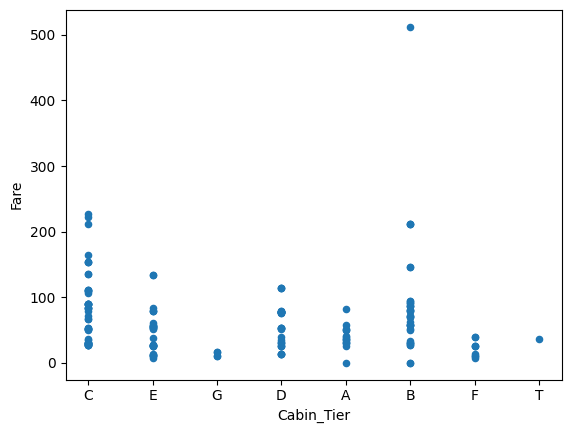

In [71]:
room_one_df = room_df[room_df['Cabin_Num']==1]
room_one_df.plot(kind='scatter', x='Cabin_Tier', y='Fare')

In [59]:
X.loc[room_df[room_df['Cabin_Num'] > 1].index]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Company
27,28,1,"Fortune, Mr. Charles Alexander",male,19.00,3,2,19950,263.0000,C23 C25 C27,S,5
75,76,3,"Moen, Mr. Sigurd Hansen",male,25.00,0,0,348123,7.6500,F G73,S,0
88,89,1,"Fortune, Miss. Mabel Helen",female,23.00,3,2,19950,263.0000,C23 C25 C27,S,5
97,98,1,"Greenfield, Mr. William Bertram",male,23.00,0,1,PC 17759,63.3583,D10 D12,C,1
118,119,1,"Baxter, Mr. Quigg Edmond",male,24.00,0,1,PC 17558,247.5208,B58 B60,C,1
128,129,3,"Peter, Miss. Anna",female,NaN,1,1,2668,22.3583,F E69,C,2
297,298,1,"Allison, Miss. Helen Loraine",female,2.00,1,2,113781,151.5500,C22 C26,S,3
299,300,1,"Baxter, Mrs. James (Helene DeLaudeniere Chaput)",female,50.00,0,1,PC 17558,247.5208,B58 B60,C,1
305,306,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,3
311,312,1,"Ryerson, Miss. Emily Borie",female,18.00,2,2,PC 17608,262.3750,B57 B59 B63 B66,C,4


In [23]:
room_df.head()


,Fare,Pclass,Cabin,Cabin_Tier
0,7.2500,3,NaN,
1,71.2833,1,C85,C
2,7.9250,3,NaN,
3,53.1000,1,C123,C
4,8.0500,3,NaN,
